**Import necessary libraries:**

In [2]:
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.base import clone
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
#Read in kg1_cleaned from the cleaned notebook
kg1 = pd.read_csv("../data/kg1_cleaned.csv")

## Modeling Setup

This section defines the shared modeling workflow used throughout the notebook.

Key rules:
- The train/test split is created **once** at the game level using `game_pk`.
- `game_pk`, and `game_date` are dropped consistently for every KG model.
- Tree models use numeric `-999` imputation and categorical `"Missing"` + one-hot encoding.
- Linear models use numeric `Median` imputation, plus numeric scaling.
- Group CV is run with the preprocessing inside the CV pipeline to avoid leakage across folds.

In [5]:
# Columns that should not be used as model features.
# game_pk is used for splitting/grouping, not prediction.
# game_date can create time leakage / unstable behavior.
# des is a text description of the pitch/play and can leak outcome information.
BASE_DROP_COLS = ["game_pk", "game_date", "des"]
TARGET_COL = "pitch_type"

**Preprocessor function to make data usable for tree and linear models:**

In [7]:
def make_preprocessor(X_train_raw, model_family="tree"):
    """
    Build a consistent preprocessing object from the training data.

    model_family="tree":
        numeric -> impute missing values as -999
        categorical -> impute as "Missing", then one-hot encode

    model_family="linear":
        numeric -> impute missing values with median, then scale
        categorical -> impute as "Missing", then one-hot encode
    """
    numeric_cols = X_train_raw.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X_train_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    if model_family == "tree":
        numeric_steps = [
            ("imputer", SimpleImputer(strategy="constant", fill_value=-999))
        ]

    elif model_family == "linear":
        numeric_steps = [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]

    else:
        raise ValueError("model_family must be either 'tree' or 'linear'")

    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_onehot_encoder())
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

**Function to generate Train/Test X and y datasets by games:**

In [9]:
def split_raw_data_by_games(df, train_games, target_col=TARGET_COL, drop_cols=BASE_DROP_COLS):
    """
    Apply the one shared game-level split to a KG dataset and return raw X/y.
    The raw X objects are used to fit either tree or linear preprocessors.
    """
    train_mask = df["game_pk"].isin(train_games)

    train_df = df.loc[train_mask].copy()
    test_df = df.loc[~train_mask].copy()

    y_train = train_df[target_col]
    y_test = test_df[target_col]

    cols_to_drop = [target_col] + list(drop_cols)
    X_train_raw = train_df.drop(columns=cols_to_drop, errors="ignore")
    X_test_raw = test_df.drop(columns=cols_to_drop, errors="ignore")

    groups = train_df["game_pk"]

    return {
        "train_df": train_df,
        "test_df": test_df,
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "y_train": y_train,
        "y_test": y_test,
        "groups": groups
    }

**Function to split original datasets into train/test split for modeling:**

In [11]:
def prepare_model_data(df, train_games, model_family="tree", target_col=TARGET_COL, drop_cols=BASE_DROP_COLS):
    """
    Split a KG dataset using the shared train_games, then fit/transform preprocessing.
    This is called once per KG/model family.
    """
    data = split_raw_data_by_games(df, train_games, target_col=target_col, drop_cols=drop_cols)

    preprocessor = make_preprocessor(data["X_train_raw"], model_family=model_family)
    X_train = preprocessor.fit_transform(data["X_train_raw"])
    X_test = preprocessor.transform(data["X_test_raw"])

    data["X_train"] = X_train
    data["X_test"] = X_test
    data["preprocessor"] = preprocessor
    data["feature_names"] = preprocessor.get_feature_names_out()
    data["model_family"] = model_family

    return data

**Function to make cross-validation pipeline:**

In [13]:
def make_cv_pipeline(model, X_train_raw, model_family):
    """
    Build a fresh pipeline for grouped CV.
    Preprocessing is fit separately inside each CV fold.
    """
    return Pipeline(steps=[
        ("preprocessor", make_preprocessor(X_train_raw, model_family=model_family)),
        ("classifier", clone(model))
    ])

**Function to evaluate model output:**

In [15]:
def evaluate_prepared_model(model, data, model_name, kg_name, model_family, results_df, show_confusion_matrix=True):
    """
    Fit a model on already-prepared train/test matrices, print evaluation output,
    run grouped CV correctly with preprocessing inside each fold, append results,
    and display the updated comparison table.
    """
    model.fit(data["X_train"], data["y_train"])

    y_pred_train = model.predict(data["X_train"])
    y_pred_test = model.predict(data["X_test"])

    train_accuracy = accuracy_score(data["y_train"], y_pred_train)
    test_accuracy = accuracy_score(data["y_test"], y_pred_test)

    print(f"{kg_name} {model_name} Training Accuracy: {train_accuracy:.4f}")
    print(f"{kg_name} {model_name} Testing Accuracy : {test_accuracy:.4f}")
    print("\nClassification Report")
    print(classification_report(data["y_test"], y_pred_test, zero_division=0))

    if show_confusion_matrix:
        cm = confusion_matrix(data["y_test"], y_pred_test, labels=model.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        fig, ax = plt.subplots(figsize=(8, 8))
        disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
        plt.title(f"{kg_name} {model_name} Confusion Matrix")
        plt.tight_layout()
        plt.show()

    cv = GroupKFold(n_splits=5)
    cv_pipeline = make_cv_pipeline(model, data["X_train_raw"], model_family=model_family)

    cv_scores = cross_val_score(
        cv_pipeline,
        data["X_train_raw"],
        data["y_train"],
        cv=cv,
        groups=data["groups"],
        scoring="accuracy",
        n_jobs=-1
    )

    cv_mean = cv_scores.mean()

    print(f"{kg_name} {model_name} Group CV Scores:", cv_scores)
    print(f"{kg_name} {model_name} Mean Group CV Accuracy: {cv_mean:.4f}")
    print(f"{kg_name} {model_name} Group CV Std: {cv_scores.std():.4f}")

    new_row = pd.DataFrame([{
        "KG Dataset": kg_name,
        "Model": model_name,
        "Preprocessing": model_family,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Group CV Accuracy": cv_mean
    }])

    results_df = pd.concat([results_df, new_row], ignore_index=True)

    display(
        results_df.assign(
            **{
                "Train Accuracy": results_df["Train Accuracy"].round(4),
                "Test Accuracy": results_df["Test Accuracy"].round(4),
                "Group CV Accuracy": results_df["Group CV Accuracy"].round(4)
            }
        )
    )

    return model, y_pred_test, results_df

**Function to evaluate naive stratified model:**

In [17]:
def evaluate_naive_stratified(data, kg_name, results_df):
    """Evaluate the stratified dummy baseline using the same train/test games and grouped CV."""
    naive_model = DummyClassifier(strategy="stratified", random_state=42)

    naive_model.fit(data["X_train_raw"], data["y_train"])
    y_pred_train = naive_model.predict(data["X_train_raw"])
    y_pred_test = naive_model.predict(data["X_test_raw"])

    train_accuracy = accuracy_score(data["y_train"], y_pred_train)
    test_accuracy = accuracy_score(data["y_test"], y_pred_test)

    print(f"{kg_name} Naive Stratified Training Accuracy: {train_accuracy:.4f}")
    print(f"{kg_name} Naive Stratified Testing Accuracy : {test_accuracy:.4f}")

    cv = GroupKFold(n_splits=5)
    cv_scores = cross_val_score(
        DummyClassifier(strategy="stratified", random_state=42),
        data["X_train_raw"],
        data["y_train"],
        cv=cv,
        groups=data["groups"],
        scoring="accuracy",
        n_jobs=-1
    )
    cv_mean = cv_scores.mean()

    print(f"{kg_name} Naive Stratified Group CV Scores:", cv_scores)
    print(f"{kg_name} Naive Stratified Mean Group CV Accuracy: {cv_mean:.4f}")

    new_row = pd.DataFrame([{
        "KG Dataset": kg_name,
        "Model": "Naive Stratified",
        "Preprocessing": "none",
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Group CV Accuracy": cv_mean
    }])

    results_df = pd.concat([results_df, new_row], ignore_index=True)

    display(
        results_df.assign(
            **{
                "Train Accuracy": results_df["Train Accuracy"].round(4),
                "Test Accuracy": results_df["Test Accuracy"].round(4),
                "Group CV Accuracy": results_df["Group CV Accuracy"].round(4)
            }
        )
    )

    return naive_model, y_pred_test, results_df

**Function to generate feature importance table:**

In [19]:
def feature_importance_table(model, feature_names, top_n=25):
    """Create a feature-importance table for tree-based models with feature_importances_."""
    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    return importance_df.head(top_n)

**Rounded model results:**

In [21]:
def rounded_results(results_df):
    """Pretty display version of the model comparison table."""
    return results_df.assign(
        **{
            "Train Accuracy": results_df["Train Accuracy"].round(4),
            "Test Accuracy": results_df["Test Accuracy"].round(4),
            "Group CV Accuracy": results_df["Group CV Accuracy"].round(4)
        }
    )


# One shared game-level train/test split for every KG iteration.
all_games = kg1["game_pk"].dropna().unique()

train_games, test_games = train_test_split(
    all_games,
    test_size=0.20,
    random_state=42
)

print(f"Train games: {len(train_games)}")
print(f"Test games : {len(test_games)}")

# Main comparison table. This gets updated after every model run.
model_results = pd.DataFrame(columns=[
    "KG Dataset",
    "Model",
    "Preprocessing",
    "Train Accuracy",
    "Test Accuracy",
    "Group CV Accuracy"
])

Train games: 222
Test games : 56


**One hot encoder to work with categorical variables**:

In [23]:
def make_onehot_encoder():
    """Create a dense one-hot encoder that works across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

## KG1 Model

KG1 is the cleaned base dataset after leakage-safe previous-pitch and previous-at-bat transformations.

For Random Forest, KG1 uses the shared tree preprocessing pipeline:
- drop `game_pk`, `game_date`, and `des`
- numeric missing values → `-999`
- categorical missing values → `"Missing"`
- one-hot encode categoricals

In [25]:

# Prepare KG1 once for tree-based models
kg1_tree_data = prepare_model_data(kg1, train_games, model_family="tree")

print("KG1 raw train shape:", kg1_tree_data["X_train_raw"].shape)
print("KG1 processed train shape:", kg1_tree_data["X_train"].shape)
print("KG1 raw test shape:", kg1_tree_data["X_test_raw"].shape)
print("KG1 processed test shape:", kg1_tree_data["X_test"].shape)


KG1 raw train shape: (19949, 114)
KG1 processed train shape: (19949, 217)
KG1 raw test shape: (4891, 114)
KG1 processed test shape: (4891, 217)


### KG1 Naive Stratified Baseline  
This stratified naive model guesses pitches based off of the overall distribution of the y variable, meaning this represents the baseline accuracy if you guessed randomly:

In [27]:
kg1_naive_model, kg1_naive_pred, model_results = evaluate_naive_stratified(
    data=kg1_tree_data,
    kg_name="KG1",
    results_df=model_results
)


KG1 Naive Stratified Training Accuracy: 0.4270
KG1 Naive Stratified Testing Accuracy : 0.4265
KG1 Naive Stratified Group CV Scores: [0.41198596 0.42614346 0.43674699 0.44249562 0.43663739]
KG1 Naive Stratified Mean Group CV Accuracy: 0.4308


/var/folders/xl/0mdbqj151h998r8m4wkx2x1c0000gn/T/ipykernel_214/387854640.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.427,0.4265,0.4308


### KG1 Random Forest

KG1 Random Forest Training Accuracy: 0.6907
KG1 Random Forest Testing Accuracy : 0.5772

Classification Report
              precision    recall  f1-score   support

          CH       0.00      0.00      0.00        74
          FF       0.57      0.92      0.71      2636
          FS       0.60      0.24      0.34      1672
          SL       0.00      0.00      0.00       504
          ST       0.00      0.00      0.00         5

    accuracy                           0.58      4891
   macro avg       0.23      0.23      0.21      4891
weighted avg       0.51      0.58      0.50      4891



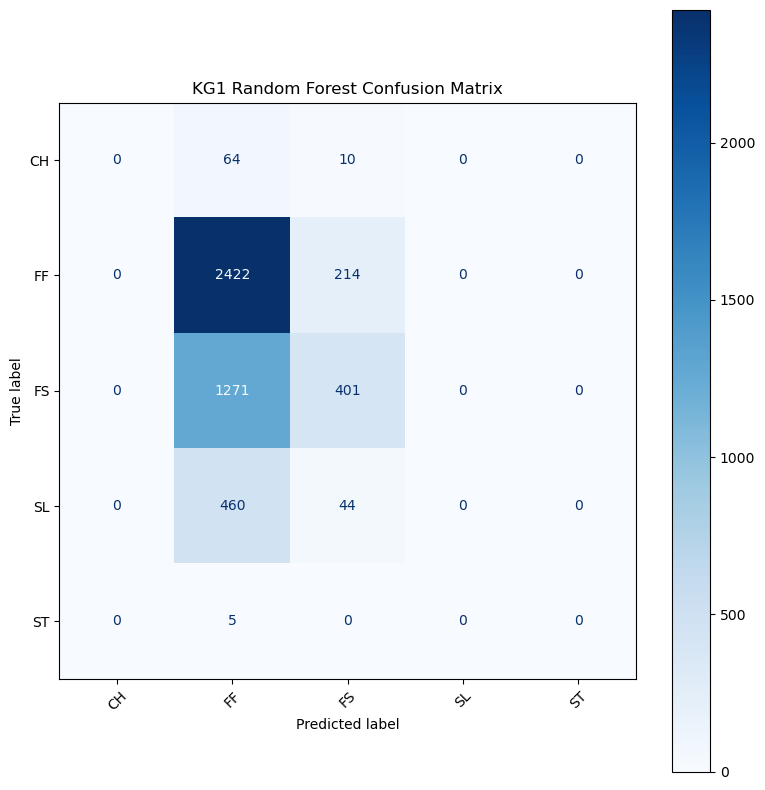

KG1 Random Forest Group CV Scores: [0.56820461 0.58885279 0.59563253 0.5995991  0.58996236]
KG1 Random Forest Mean Group CV Accuracy: 0.5885
KG1 Random Forest Group CV Std: 0.0108


,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.4270,0.4265,0.4308
1,KG1,Random Forest,tree,0.6907,0.5772,0.5885


In [29]:

kg1_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features="log2",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

kg1_rf, kg1_rf_pred, model_results = evaluate_prepared_model(
    model=kg1_rf,
    data=kg1_tree_data,
    model_name="Random Forest",
    kg_name="KG1",
    model_family="tree",
    results_df=model_results
)


## KG2 Edits

KG2 starts from KG1, then removes lower-level/redundant variables and adds more interpretable baseball context features.

In [31]:
kg2 = kg1.copy()


In [32]:
#remove intentional walk rows
kg2 = kg2.dropna(subset=["pitch_type"]).copy()

**Rename variables for clarity:**

In [34]:
kg2.rename(columns={'pitch_number': 'pitch_number_of_ab', "at_bat_number": "at_bat_number_of_game"}, inplace=True)

### Drop variables
Here, we drop the redundant pitch characteristic variables:

In [36]:
# =========================
# Create kg2: Interpretable Front-Office Model Dataset
# =========================
remove_from_kg2 = [
    # Low-level trajectory variables
    "vx0_of_prev_pitch",
    "vy0_of_prev_pitch",
    "vz0_of_prev_pitch",
    "ax_of_prev_pitch",
    "ay_of_prev_pitch",
    "az_of_prev_pitch",
    "plate_z_of_prev_pitch",
    "plate_x_of_prev_pitch",
    "pfx_z_of_prev_pitch",
    "pfx_x_of_prev_pitch",

    # API / derived break variables
    "api_break_z_with_gravity_of_prev_pitch",
    "api_break_x_arm_of_prev_pitch",
    "api_break_x_batter_in_of_prev_pitch",

    # Hawkeye / swing-mechanics variables
    "attack_angle_of_prev_pitch",
    "hyper_speed_of_prev_pitch",
    "attack_direction_of_prev_pitch",
    "swing_length_of_prev_pitch",
    "intercept_ball_minus_batter_pos_x_inches_of_prev_pitch",
    "intercept_ball_minus_batter_pos_y_inches_of_prev_pitch",
    "swing_path_tilt_of_prev_pitch",

    # Dense release / spin / location variables removed for kg2
    "arm_angle_of_prev_pitch",
    "release_spin_rate_of_prev_pitch",
    "spin_axis_of_prev_pitch",
    "release_extension_of_prev_pitch",
    "release_pos_x_of_prev_pitch",
    "release_pos_y_of_prev_pitch",
    "release_pos_z_of_prev_pitch",

    # IDs / deprecated / non-useful fields
    "sv_id",
    "game_year",
    "tfs_deprecated",
    "tfs_zulu_deprecated",
    "spin_dir",
    "spin_rate_deprecated",
    "break_angle_deprecated",
    "break_length_deprecated",
    "des"
]

kg2 = kg2.drop(columns=remove_from_kg2, errors="ignore")

print("kg1 shape:", kg1.shape)
print("kg2 shape:", kg2.shape)
print("Columns removed:", kg1.shape[1] - kg2.shape[1])

kg1 shape: (24840, 118)
kg2 shape: (24840, 82)
Columns removed: 36


### Creating new features:

**Previous Pitch Type**

In [39]:
# Create previous pitch type (within each game)

kg2["pitch_type_of_prev_pitch"] = (
    kg2.sort_values(["game_pk", "at_bat_number_of_game", "pitch_number_of_ab"])
       .groupby("game_pk")["pitch_type"]
       .shift(1)
)

In [40]:
kg2.head()

,game_date,pitch_number_of_ab,at_bat_number_of_game,events_of_prev_ab,hit_location_of_prev_ab,bb_type_of_prev_ab,estimated_ba_using_speedangle_of_prev_ab,estimated_woba_using_speedangle_of_prev_ab,woba_value_of_prev_ab,woba_denom_of_prev_ab,...,delta_home_win_exp_of_prev_pitch,delta_run_exp_of_prev_pitch,bat_speed_of_prev_pitch,miss_distance_of_prev_pitch,estimated_slg_using_speedangle_of_prev_pitch,delta_pitcher_run_exp_of_prev_pitch,hit_distance_sc_of_prev_pitch,launch_speed_of_prev_pitch,launch_angle_of_prev_pitch,pitch_type_of_prev_pitch
0,2017-04-28,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-04-28,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.005,0.056,NaN,NaN,NaN,-0.056,NaN,NaN,NaN,FF
2,2017-04-28,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.010,0.131,NaN,NaN,NaN,-0.131,NaN,NaN,NaN,FS
3,2017-04-28,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.009,-0.089,NaN,NaN,NaN,0.089,NaN,NaN,NaN,FF
4,2017-04-28,1,1,walk,NaN,NaN,NaN,0.692994,0.7,1.0,...,0.030,0.349,NaN,NaN,NaN,-0.349,NaN,NaN,NaN,FF


**Pitcher/Hitter Handedness**

In [42]:
# Create binary feature: 1 if pitcher and batter have the same handedness, 0 otherwise
kg2["p/h_hand"] = (kg2["p_throws"] == kg2["stand"]).astype(int)

**Count Leverage Indicator**

In [44]:
# Create exact count feature
kg2["count"] = (
    kg2["balls"].astype(int).astype(str)
    + "-"
    + kg2["strikes"].astype(int).astype(str)
)

In [45]:
def classify_count(row):
    balls = row["balls"]
    strikes = row["strikes"]

    if balls == 3 and strikes == 2:
        return "full_count"
    elif strikes == 2 and balls < 3:
        return "put_away_count"
    elif balls >= 2 and strikes <= 1:
        return "hitters_count"
    elif strikes > balls:
        return "pitcher_ahead"
    elif balls > strikes:
        return "pitcher_behind"
    else:
        return "even_count"

kg2["count_state"] = kg2.apply(classify_count, axis=1)

**Pitch Number of Game**

In [47]:
# Pitch number within the game (1, 2, 3, ...)
kg2["pitch_number_of_game"] = (
    kg2.groupby("game_pk").cumcount() + 1
)

**Number of Career Matchups**

In [49]:
# Sort chronologically across seasons
kg2 = kg2.sort_values(
    ["game_date", "game_pk", "at_bat_number_of_game", "pitch_number_of_ab"]
).reset_index(drop=True)

# One row per plate appearance / at-bat
pa_level = (
    kg2[["game_date", "game_pk", "at_bat_number_of_game", "pitcher", "batter"]]
    .drop_duplicates(subset=["game_pk", "at_bat_number_of_game"])
    .sort_values(["game_date", "game_pk", "at_bat_number_of_game"])
    .copy()
)

# Previous career PAs this batter has had against this pitcher
pa_level["prior_pa_vs_pitcher_career"] = (
    pa_level
    .groupby(["pitcher", "batter"])
    .cumcount()
)

# Merge back onto every pitch
kg2 = kg2.merge(
    pa_level[["game_pk", "at_bat_number_of_game", "prior_pa_vs_pitcher_career"]],
    on=["game_pk", "at_bat_number_of_game"],
    how="left"
)

**Pitcher Team Lead**

In [51]:
kg2["pitcher_team_score_diff"] = kg2["fld_score"] - kg2["bat_score"]

**Strike Zone Height**

In [53]:
kg2['strike_zone_height'] = kg2.sz_top - kg2.sz_bot

## KG2 Model


In [55]:
# Prepare KG2 once for tree-based models
kg2_tree_data = prepare_model_data(kg2, train_games, model_family="tree")

print("KG2 raw train shape:", kg2_tree_data["X_train_raw"].shape)
print("KG2 processed train shape:", kg2_tree_data["X_train"].shape)
print("KG2 raw test shape:", kg2_tree_data["X_test_raw"].shape)
print("KG2 processed test shape:", kg2_tree_data["X_test"].shape)


KG2 raw train shape: (19949, 87)
KG2 processed train shape: (19949, 211)
KG2 raw test shape: (4891, 87)
KG2 processed test shape: (4891, 211)


### KG2 Random Forest

KG2 Random Forest Training Accuracy: 0.6859
KG2 Random Forest Testing Accuracy : 0.5852

Classification Report
              precision    recall  f1-score   support

          CH       0.00      0.00      0.00        74
          FF       0.58      0.89      0.70      2636
          FS       0.60      0.31      0.41      1672
          SL       0.00      0.00      0.00       504
          ST       0.00      0.00      0.00         5

    accuracy                           0.59      4891
   macro avg       0.24      0.24      0.22      4891
weighted avg       0.52      0.59      0.52      4891



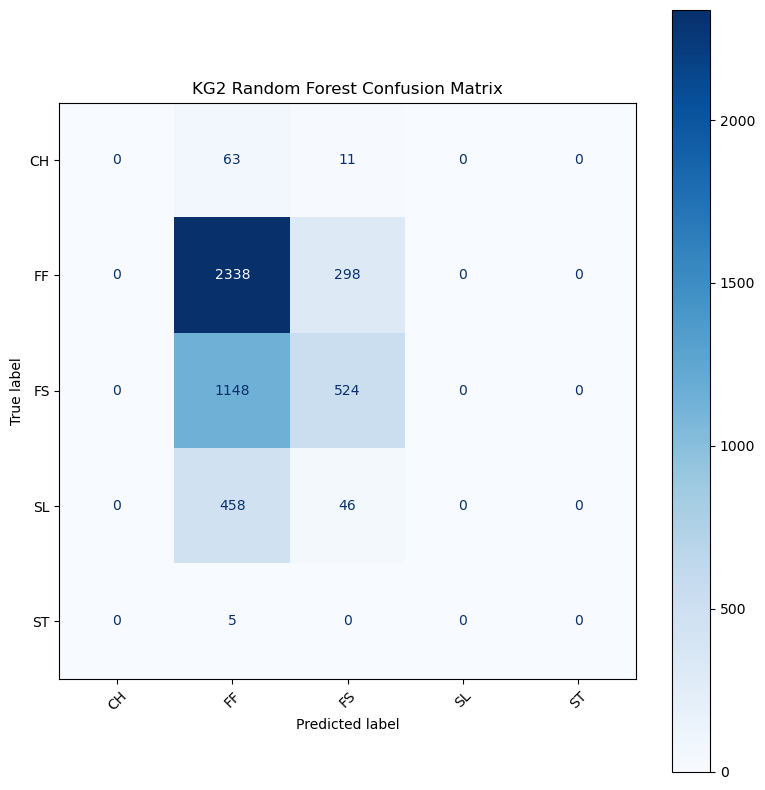

KG2 Random Forest Group CV Scores: [0.57798395 0.59860035 0.60843373 0.60185417 0.58795483]
KG2 Random Forest Mean Group CV Accuracy: 0.5950
KG2 Random Forest Group CV Std: 0.0108


,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.4270,0.4265,0.4308
1,KG1,Random Forest,tree,0.6907,0.5772,0.5885
2,KG2,Random Forest,tree,0.6859,0.5852,0.5950


In [57]:
kg2_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features="log2",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

kg2_rf, kg2_rf_pred, model_results = evaluate_prepared_model(
    model=kg2_rf,
    data=kg2_tree_data,
    model_name="Random Forest",
    kg_name="KG2",
    model_family="tree",
    results_df=model_results
)


## KG3 Edits

KG3 starts from KG2, removes additional features, and adds rolling previous-pitch-mix features.

### Remove unnecessary features:

In [60]:
#Create kg3
kg3 = kg2.copy()

kg3_drop_cols = [
    "effective_speed_of_prev_pitch",
    "delta_home_win_exp_of_prev_pitch",
    "home_win_exp",
    "age_bat_legacy",
    "post_home_score",
    "fielder_2",
    "fielder_3",
    "fielder_4",
    "fielder_5",
    "fielder_6",
    "fielder_7",
    "fielder_8",
    "fielder_9",
    "home_score",
    "away_score",
    "home_score_diff",
    "age_pit_legacy",
    "pitcher_days_until_next_game",
    "batter_days_until_next_game",
    "player_name",
    "batter_days_since_prev_game",
    "p/h_hand"
    
]

kg3 = kg3.drop(columns=kg3_drop_cols)

kg3.shape

(24840, 68)

### Add new features:

**Previous 3 Pitches**

In [63]:
# -------------------------
# KG3 rolling pitch mix: previous 3 pitches
# Uses pitch_type, then shifts backward so current pitch is excluded
# -------------------------

kg3 = kg3.sort_values(
    ["game_date", "game_pk", "at_bat_number_of_game", "pitch_number_of_ab"]
).reset_index(drop=True)

pitch_dummies_3 = pd.get_dummies(
    kg3["pitch_type"],
    prefix="prev3_pitch_rate"
)

# Shift within pitcher so each row only sees pitches BEFORE the current pitch
pitch_dummies_3_shifted = (
    pitch_dummies_3
    .groupby(kg3["pitcher"])
    .shift(1)
)

rolling_3 = (
    pitch_dummies_3_shifted
    .groupby(kg3["pitcher"])
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

kg3 = pd.concat([kg3, rolling_3], axis=1)

In [64]:
kg3.head(20)

,game_date,pitch_number_of_ab,at_bat_number_of_game,events_of_prev_ab,hit_location_of_prev_ab,bb_type_of_prev_ab,estimated_ba_using_speedangle_of_prev_ab,estimated_woba_using_speedangle_of_prev_ab,woba_value_of_prev_ab,woba_denom_of_prev_ab,...,count_state,pitch_number_of_game,prior_pa_vs_pitcher_career,pitcher_team_score_diff,strike_zone_height,prev3_pitch_rate_CH,prev3_pitch_rate_FF,prev3_pitch_rate_FS,prev3_pitch_rate_SL,prev3_pitch_rate_ST
0,2017-04-28,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,even_count,1,0,4,1.688094,NaN,NaN,NaN,NaN,NaN
1,2017-04-28,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,hitters_count,2,0,4,1.736089,0.0,1.000000,0.000000,0.000000,0.0
2,2017-04-28,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,hitters_count,3,0,4,1.704043,0.0,0.500000,0.500000,0.000000,0.0
3,2017-04-28,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,full_count,4,0,4,1.927603,0.0,0.666667,0.333333,0.000000,0.0
4,2017-04-28,1,1,walk,NaN,NaN,NaN,0.692994,0.7,1.0,...,even_count,5,0,4,2.027311,0.0,0.666667,0.333333,0.000000,0.0
5,2017-04-28,2,1,walk,NaN,NaN,NaN,0.692994,0.7,1.0,...,pitcher_behind,6,0,4,2.219007,0.0,1.000000,0.000000,0.000000,0.0
6,2017-04-28,1,2,grounded_into_double_play,6.0,ground_ball,0.085,0.077000,0.0,1.0,...,even_count,7,0,4,1.779910,0.0,0.666667,0.000000,0.333333,0.0
7,2017-04-28,2,2,grounded_into_double_play,6.0,ground_ball,0.085,0.077000,0.0,1.0,...,pitcher_ahead,8,0,4,2.179052,0.0,0.666667,0.000000,0.333333,0.0
8,2017-04-28,3,2,grounded_into_double_play,6.0,ground_ball,0.085,0.077000,0.0,1.0,...,put_away_count,9,0,4,1.620136,0.0,0.666667,0.000000,0.333333,0.0
9,2017-04-28,4,2,grounded_into_double_play,6.0,ground_ball,0.085,0.077000,0.0,1.0,...,put_away_count,10,0,4,1.700017,0.0,0.666667,0.333333,0.000000,0.0


## KG3 Model


In [66]:
# Prepare KG3 once for tree-based models
kg3_tree_data = prepare_model_data(kg3, train_games, model_family="tree")

print("KG3 raw train shape:", kg3_tree_data["X_train_raw"].shape)
print("KG3 processed train shape:", kg3_tree_data["X_train"].shape)
print("KG3 raw test shape:", kg3_tree_data["X_test_raw"].shape)
print("KG3 processed test shape:", kg3_tree_data["X_test"].shape)


KG3 raw train shape: (19949, 70)
KG3 processed train shape: (19949, 194)
KG3 raw test shape: (4891, 70)
KG3 processed test shape: (4891, 194)


### KG3 Random Forest

KG3 Random Forest Training Accuracy: 0.6759
KG3 Random Forest Testing Accuracy : 0.5874

Classification Report
              precision    recall  f1-score   support

          CH       0.00      0.00      0.00        74
          FF       0.58      0.89      0.71      2636
          FS       0.60      0.31      0.41      1672
          SL       0.00      0.00      0.00       504
          ST       0.00      0.00      0.00         5

    accuracy                           0.59      4891
   macro avg       0.24      0.24      0.22      4891
weighted avg       0.52      0.59      0.52      4891



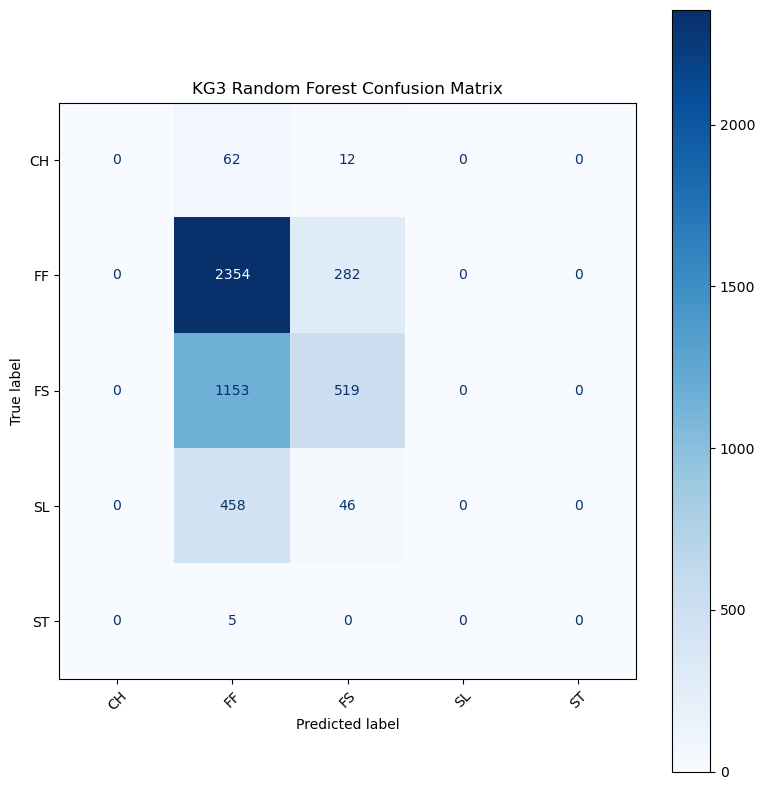

KG3 Random Forest Group CV Scores: [0.57748245 0.5956011  0.60993976 0.59734402 0.58745295]
KG3 Random Forest Mean Group CV Accuracy: 0.5936
KG3 Random Forest Group CV Std: 0.0108


,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.4270,0.4265,0.4308
1,KG1,Random Forest,tree,0.6907,0.5772,0.5885
2,KG2,Random Forest,tree,0.6859,0.5852,0.5950
3,KG3,Random Forest,tree,0.6759,0.5874,0.5936


In [68]:
kg3_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features="log2",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

kg3_rf, kg3_rf_pred, model_results = evaluate_prepared_model(
    model=kg3_rf,
    data=kg3_tree_data,
    model_name="Random Forest",
    kg_name="KG3",
    model_family="tree",
    results_df=model_results
)


### KG3 Random Forest Feature Importance

In [70]:
kg3_rf_importance = feature_importance_table(
    model=kg3_rf,
    feature_names=kg3_tree_data["feature_names"],
    top_n=25
)

kg3_rf_importance


,Feature,Importance
0,num__delta_pitcher_run_exp_of_prev_pitch,0.039862
1,num__delta_run_exp_of_prev_pitch,0.038718
2,cat__count_state_put_away_count,0.027948
3,num__release_speed_of_prev_pitch,0.027318
4,num__strikes,0.027277
5,num__pitch_number_of_ab,0.024526
6,num__age_pit,0.024046
7,num__pitch_number_of_game,0.023258
8,num__batter,0.023073
9,num__strike_zone_height,0.020668


## KG4 Edits

KG4 uses only the variables readily available to players, managers and fans at a live game level. `game_pk` and `game_date` are retained only for splitting/dropping and are not included as model features.


In [72]:
# -------------------------
# Create kg4
# -------------------------

kg4_cols = [
    "game_date",
    "pitch_number_of_ab",
    "at_bat_number_of_game",
    "events_of_prev_ab",
    "hit_location_of_prev_ab",
    "bb_type_of_prev_ab",
    "launch_speed_angle_of_prev_ab",
    "inning",
    "n_thruorder_pitcher",
    "pitch_type",
    "batter",
    "pitcher",
    "game_type",
    "stand",
    "p_throws",
    "home_team",
    "away_team",
    "balls",
    "strikes",
    "on_3b",
    "on_2b",
    "on_1b",
    "outs_when_up",
    "inning_topbot",
    "sz_top",
    "sz_bot",
    "game_pk",
    "bat_score",
    "fld_score",
    "if_fielding_alignment",
    "of_fielding_alignment",
    "bat_win_exp",
    "age_pit",
    "age_bat",
    "n_priorpa_thisgame_player_at_bat",
    "pitcher_days_since_prev_game",
    "release_speed_of_prev_pitch",
    "description_of_prev_pitch",
    "zone_of_prev_pitch",
    "type_of_prev_pitch",
    "hit_distance_sc_of_prev_pitch",
    "launch_speed_of_prev_pitch",
    "launch_angle_of_prev_pitch",
    "pitch_type_of_prev_pitch",
    "count",
    "count_state",
    "pitch_number_of_game",
    "prior_pa_vs_pitcher_career",
    "pitcher_team_score_diff",
    "strike_zone_height",
    "prev3_pitch_rate_CH",
    "prev3_pitch_rate_FF",
    "prev3_pitch_rate_FS",
    "prev3_pitch_rate_SI",
    "prev3_pitch_rate_SL",
    "prev3_pitch_rate_ST",
]

kg4 = kg3[kg4_cols].copy()

# game_pk and game_date stay in kg4 so the shared split works,
# but BASE_DROP_COLS removes them before modeling.
kg4.head()


,game_date,pitch_number_of_ab,at_bat_number_of_game,events_of_prev_ab,hit_location_of_prev_ab,bb_type_of_prev_ab,launch_speed_angle_of_prev_ab,inning,n_thruorder_pitcher,pitch_type,...,count_state,pitch_number_of_game,prior_pa_vs_pitcher_career,pitcher_team_score_diff,strike_zone_height,prev3_pitch_rate_CH,prev3_pitch_rate_FF,prev3_pitch_rate_FS,prev3_pitch_rate_SL,prev3_pitch_rate_ST
0,2017-04-28,3,0,NaN,NaN,NaN,NaN,5,2,FF,...,even_count,1,0,4,1.688094,NaN,NaN,NaN,NaN,NaN
1,2017-04-28,4,0,NaN,NaN,NaN,NaN,5,2,FS,...,hitters_count,2,0,4,1.736089,0.0,1.000000,0.000000,0.0,0.0
2,2017-04-28,5,0,NaN,NaN,NaN,NaN,5,2,FF,...,hitters_count,3,0,4,1.704043,0.0,0.500000,0.500000,0.0,0.0
3,2017-04-28,6,0,NaN,NaN,NaN,NaN,5,2,FF,...,full_count,4,0,4,1.927603,0.0,0.666667,0.333333,0.0,0.0
4,2017-04-28,1,1,walk,NaN,NaN,NaN,5,2,FF,...,even_count,5,0,4,2.027311,0.0,0.666667,0.333333,0.0,0.0


## KG4 Model


In [74]:
# Prepare KG4 once for tree-based models
kg4_tree_data = prepare_model_data(kg4, train_games, model_family="tree")

print("KG4 raw train shape:", kg4_tree_data["X_train_raw"].shape)
print("KG4 processed train shape:", kg4_tree_data["X_train"].shape)
print("KG4 raw test shape:", kg4_tree_data["X_test_raw"].shape)
print("KG4 processed test shape:", kg4_tree_data["X_test"].shape)


KG4 raw train shape: (19949, 52)
KG4 processed train shape: (19949, 176)
KG4 raw test shape: (4891, 52)
KG4 processed test shape: (4891, 176)


### KG4 Random Forest


KG4 Random Forest Training Accuracy: 0.6664
KG4 Random Forest Testing Accuracy : 0.5800

Classification Report
              precision    recall  f1-score   support

          CH       0.00      0.00      0.00        74
          FF       0.58      0.89      0.70      2636
          FS       0.59      0.29      0.39      1672
          SL       0.00      0.00      0.00       504
          ST       0.00      0.00      0.00         5

    accuracy                           0.58      4891
   macro avg       0.23      0.24      0.22      4891
weighted avg       0.51      0.58      0.51      4891



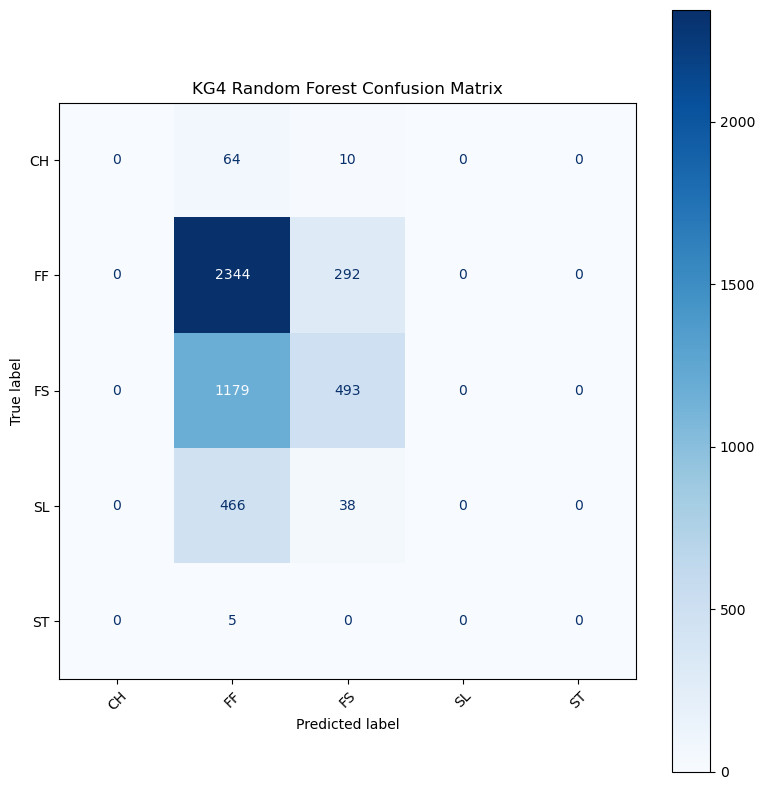

KG4 Random Forest Group CV Scores: [0.57497492 0.5956011  0.60742972 0.59208218 0.5804266 ]
KG4 Random Forest Mean Group CV Accuracy: 0.5901
KG4 Random Forest Group CV Std: 0.0115


,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.4270,0.4265,0.4308
1,KG1,Random Forest,tree,0.6907,0.5772,0.5885
2,KG2,Random Forest,tree,0.6859,0.5852,0.5950
3,KG3,Random Forest,tree,0.6759,0.5874,0.5936
4,KG4,Random Forest,tree,0.6664,0.5800,0.5901


In [76]:
kg4_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features="log2",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

kg4_rf, kg4_rf_pred, model_results = evaluate_prepared_model(
    model=kg4_rf,
    data=kg4_tree_data,
    model_name="Random Forest",
    kg_name="KG4",
    model_family="tree",
    results_df=model_results
)


### KG4 Random Forest Feature Importance


In [78]:
kg4_rf_importance = feature_importance_table(
    model=kg4_rf,
    feature_names=kg4_tree_data["feature_names"],
    top_n=25
)

kg4_rf_importance


,Feature,Importance
0,num__strikes,0.034611
1,num__release_speed_of_prev_pitch,0.034132
2,cat__count_state_put_away_count,0.032146
3,num__pitch_number_of_ab,0.030542
4,num__pitch_number_of_game,0.030075
5,num__batter,0.028310
6,num__age_pit,0.028273
7,num__strike_zone_height,0.025801
8,num__sz_bot,0.025281
9,num__sz_top,0.024948


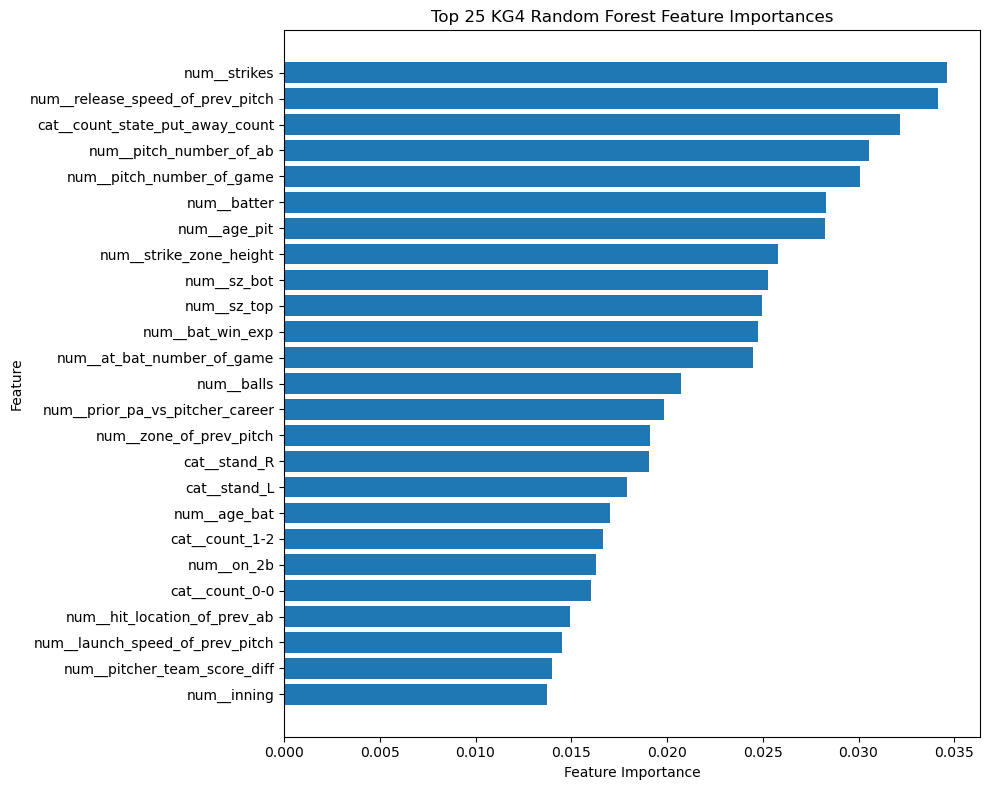

In [157]:
plot_df = (
    kg4_rf_importance
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["Feature"], plot_df["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 25 KG4 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

There doesn't seem to be one defining predictive characteristic, but there seems to be some combination of count factors, game situation, location and speed of previous pitch, and how far into the game it is

## Additional Models on KG4


In [80]:
# Prepare KG3 once for linear/distance-based models
kg4_linear_data = prepare_model_data(kg4, train_games, model_family="linear")

print("KG4 linear raw train shape:", kg4_linear_data["X_train_raw"].shape)
print("KG4 linear processed train shape:", kg4_linear_data["X_train"].shape)
print("KG4 linear raw test shape:", kg4_linear_data["X_test_raw"].shape)
print("KG4 linear processed test shape:", kg4_linear_data["X_test"].shape)


KG4 linear raw train shape: (19949, 52)
KG4 linear processed train shape: (19949, 176)
KG4 linear raw test shape: (4891, 52)
KG4 linear processed test shape: (4891, 176)


### Logistic Regression

KG4 Logistic Regression Training Accuracy: 0.5826
KG4 Logistic Regression Testing Accuracy : 0.5543

Classification Report
              precision    recall  f1-score   support

          CH       0.30      0.08      0.13        74
          FF       0.57      0.81      0.67      2636
          FS       0.54      0.34      0.42      1672
          SL       0.15      0.00      0.01       504
          ST       0.00      0.00      0.00         5

    accuracy                           0.55      4891
   macro avg       0.31      0.25      0.24      4891
weighted avg       0.51      0.55      0.51      4891



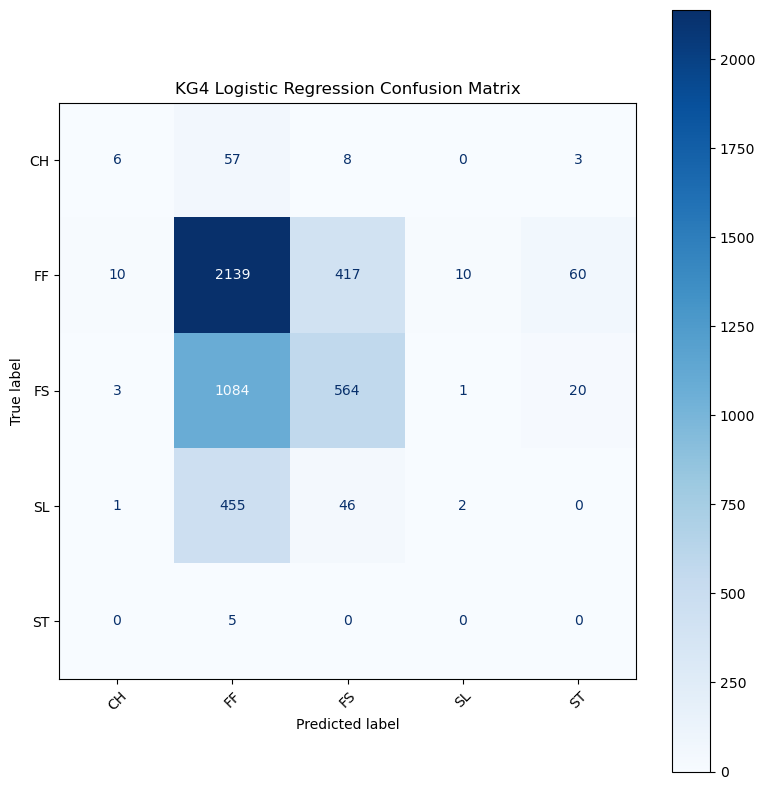

KG4 Logistic Regression Group CV Scores: [0.54613842 0.57885529 0.57404618 0.57203708 0.55181932]
KG4 Logistic Regression Mean Group CV Accuracy: 0.5646
KG4 Logistic Regression Group CV Std: 0.0131


,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.4270,0.4265,0.4308
1,KG1,Random Forest,tree,0.6907,0.5772,0.5885
2,KG2,Random Forest,tree,0.6859,0.5852,0.5950
3,KG3,Random Forest,tree,0.6759,0.5874,0.5936
4,KG4,Random Forest,tree,0.6664,0.5800,0.5901
5,KG4,Logistic Regression,linear,0.5826,0.5543,0.5646


In [82]:
kg4_logreg = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
)

kg4_logreg, kg4_logreg_pred, model_results = evaluate_prepared_model(
    model=kg4_logreg,
    data=kg4_linear_data,
    model_name="Logistic Regression",
    kg_name="KG4",
    model_family="linear",
    results_df=model_results
)


### Gradient Boosting

KG4 Gradient Boosting Training Accuracy: 0.6861
KG4 Gradient Boosting Testing Accuracy : 0.5811

Classification Report
              precision    recall  f1-score   support

          CH       0.00      0.00      0.00        74
          FF       0.59      0.83      0.69      2636
          FS       0.56      0.39      0.46      1672
          SL       0.17      0.00      0.01       504
          ST       0.00      0.00      0.00         5

    accuracy                           0.58      4891
   macro avg       0.26      0.24      0.23      4891
weighted avg       0.53      0.58      0.53      4891



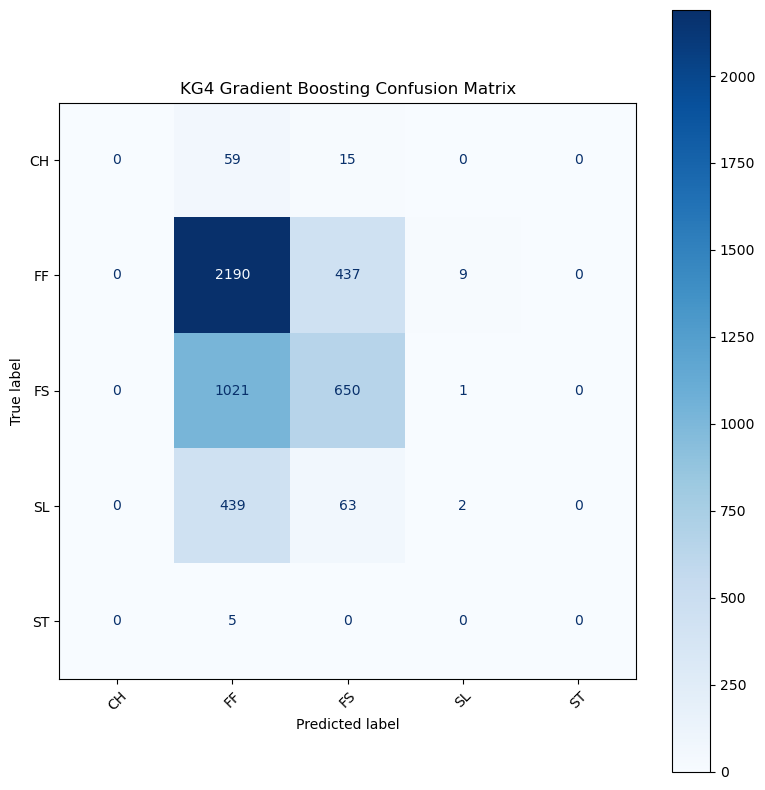

KG4 Gradient Boosting Group CV Scores: [0.57547643 0.59485129 0.60918675 0.5878226  0.5761606 ]
KG4 Gradient Boosting Mean Group CV Accuracy: 0.5887
KG4 Gradient Boosting Group CV Std: 0.0126


,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.4270,0.4265,0.4308
1,KG1,Random Forest,tree,0.6907,0.5772,0.5885
2,KG2,Random Forest,tree,0.6859,0.5852,0.5950
3,KG3,Random Forest,tree,0.6759,0.5874,0.5936
4,KG4,Random Forest,tree,0.6664,0.5800,0.5901
5,KG4,Logistic Regression,linear,0.5826,0.5543,0.5646
6,KG4,Gradient Boosting,tree,0.6861,0.5811,0.5887


In [84]:
kg4_gb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

kg4_gb, kg4_gb_pred, model_results = evaluate_prepared_model(
    model=kg4_gb,
    data=kg4_tree_data,
    model_name="Gradient Boosting",
    kg_name="KG4",
    model_family="tree",
    results_df=model_results
)


### KG3 Linear SVM

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


KG4 Linear SVM Training Accuracy: 0.5839
KG4 Linear SVM Testing Accuracy : 0.5563

Classification Report
              precision    recall  f1-score   support

          CH       0.00      0.00      0.00        74
          FF       0.57      0.82      0.67      2636
          FS       0.54      0.34      0.41      1672
          SL       0.00      0.00      0.00       504
          ST       0.00      0.00      0.00         5

    accuracy                           0.56      4891
   macro avg       0.22      0.23      0.22      4891
weighted avg       0.49      0.56      0.51      4891



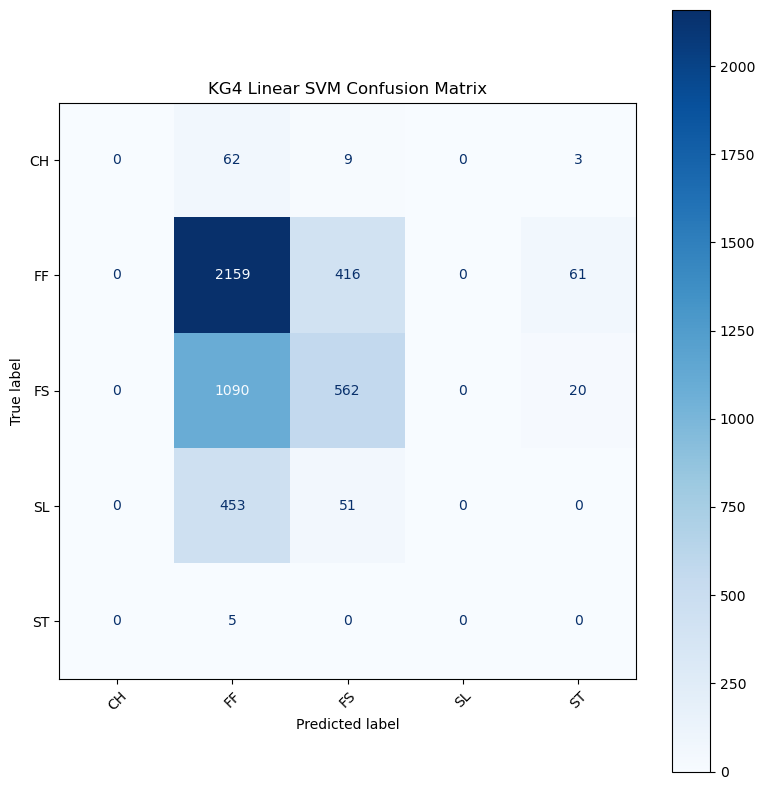

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


KG4 Linear SVM Group CV Scores: [0.55165496 0.5776056  0.58458835 0.57153596 0.56110414]
KG4 Linear SVM Mean Group CV Accuracy: 0.5693
KG4 Linear SVM Group CV Std: 0.0117


,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.4270,0.4265,0.4308
1,KG1,Random Forest,tree,0.6907,0.5772,0.5885
2,KG2,Random Forest,tree,0.6859,0.5852,0.5950
3,KG3,Random Forest,tree,0.6759,0.5874,0.5936
4,KG4,Random Forest,tree,0.6664,0.5800,0.5901
5,KG4,Logistic Regression,linear,0.5826,0.5543,0.5646
6,KG4,Gradient Boosting,tree,0.6861,0.5811,0.5887
7,KG4,Linear SVM,linear,0.5839,0.5563,0.5693


In [86]:
kg4_svm = LinearSVC(
    C=1.0,
    class_weight=None,
    max_iter=5000,
    random_state=42
)

kg4_svm, kg4_svm_pred, model_results = evaluate_prepared_model(
    model=kg4_svm,
    data=kg4_linear_data,
    model_name="Linear SVM",
    kg_name="KG4",
    model_family="linear",
    results_df=model_results
)


## Final Model Comparison Table

In [88]:
final_model_comparison = rounded_results(model_results)
final_model_comparison

,KG Dataset,Model,Preprocessing,Train Accuracy,Test Accuracy,Group CV Accuracy
0,KG1,Naive Stratified,none,0.4270,0.4265,0.4308
1,KG1,Random Forest,tree,0.6907,0.5772,0.5885
2,KG2,Random Forest,tree,0.6859,0.5852,0.5950
3,KG3,Random Forest,tree,0.6759,0.5874,0.5936
4,KG4,Random Forest,tree,0.6664,0.5800,0.5901
5,KG4,Logistic Regression,linear,0.5826,0.5543,0.5646
6,KG4,Gradient Boosting,tree,0.6861,0.5811,0.5887
7,KG4,Linear SVM,linear,0.5839,0.5563,0.5693


## Results and Conclusion

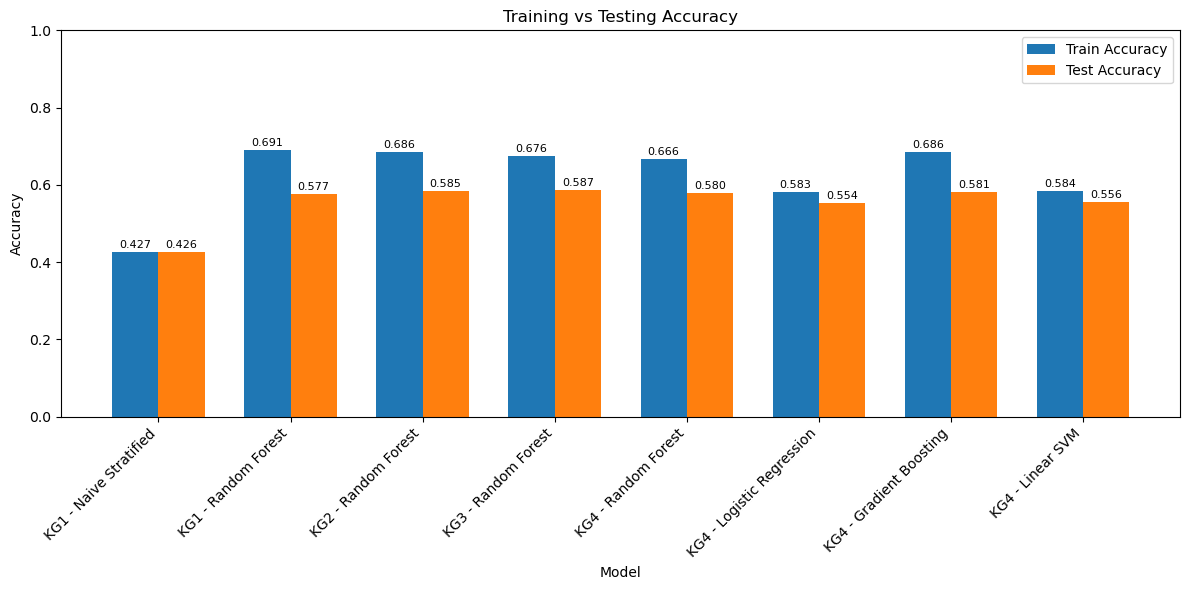

In [90]:
#plot data
plot_df = model_results.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 6))

# Bars
plt.bar(x - width/2, plot_df["Train Accuracy"], width, label="Train Accuracy")
plt.bar(x + width/2, plot_df["Test Accuracy"], width, label="Test Accuracy")

# Labels
plt.xticks(
    x,
    plot_df["KG Dataset"] + " - " + plot_df["Model"],
    rotation=45,
    ha="right"
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Training vs Testing Accuracy")
plt.ylim(0, 1)
plt.legend()

# Value labels
for i, value in enumerate(plot_df["Train Accuracy"]):
    plt.text(i - width/2, value + 0.01, f"{value:.3f}",
             ha="center", fontsize=8)

for i, value in enumerate(plot_df["Test Accuracy"]):
    plt.text(i + width/2, value + 0.01, f"{value:.3f}",
             ha="center", fontsize=8)

plt.tight_layout()
plt.show()

It appears that all of our model iterations, from `kg1` to `kg4`, all are the same ballpark of testing accuracy around **58%**, which is a **36.15%** increase over our stratified naive accuracy of **42.6%**. This demonstrates that our model is able to predict pitches more accurately than a random guesser, but isn't able to fully predict with 100% confidence by any means. In addition, it shows that most of our predictive power stems by virtue of the dataset itself, and not the feature engineering process, as almost all of our gains came from the initial preprocessing and cleaning process going from kg0 to kg1.
Our two linear models, `Logistic Regression` and `Linear SVM`, do not perform as well as our tree-based models, with testing accuracies of **55.4%** and **55.6%**. On the other hand, our `Gradient Boosting` model performs as well as our `Random Forest` models, with a testing accuracy of **58.1%**.

Overall, **our best performing model was the `kg2` version of the Random Forest**, but **the simplified `kg4` model performed relatively just as well with much more available and digestable features**. The kg4 data version was designed to only contain features readily available to fans, managers and players as the game progresses, cutting out the more dense Statcast-required or overly physics-ey or statistical variables. This would allow for live-game analysis if implemented into a MLB.com Gameday interface for example.
